### Task 1: Regression Analysis

#### Dataset: Boston Housing Dataset
Source: Originally published by Harrison, D. and Rubinfeld, D.L. (1978), 
'Hedonic prices and the demand for clean air', J. Environ. Economics & Management.

The dataset contains no column headers in the raw file. Column names have been 
assigned based on the original dataset documentation, which is widely referenced 
in machine learning literature and available via the UCI Machine Learning Repository 
and scikit-learn's built-in datasets.

Reference: https://www.cs.toronto.edu/~delve/data/boston/bostonDetail.html


#### Variables in order:
| Column | Description |
|--------|-------------|
| CRIM | Per capita crime rate by town |
| ZN | Proportion of residential land zoned for lots over 25,000 sq.ft. |
| INDUS | Proportion of non-retail business acres per town |
| CHAS | Charles River dummy variable (1 if tract bounds river; 0 otherwise) |
| NOX | Nitric oxides concentration (parts per 10 million) |
| RM | Average number of rooms per dwelling |
| AGE | Proportion of owner-occupied units built prior to 1940 |
| DIS | Weighted distances to five Boston employment centres |
| RAD | Index of accessibility to radial highways |
| TAX | Full-value property-tax rate per \$10,000 |
| PTRATIO | Pupil-teacher ratio by town |
| B | 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town |
| LSTAT | % lower status of the population |
| MEDV | Median value of owner-occupied homes in $1000's (**Target Variable**) |

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [4]:
cols = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
df = pd.read_csv('4) house Prediction Data Set.csv', sep=r'\s+', header=None, names=cols)
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [6]:
#Checking the number of rows and columns.
df.shape

(506, 14)

In [7]:
#Checking for missing values
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [ ]:
#Since there are no missing values, we split the data into X (features) and Y(Target)

In [8]:
X = df.drop('MEDV', axis=1)
y = df['MEDV']

In [9]:
#Now we split the data into training and testing datasets using the 80-20 rule
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (404, 13)
Testing set size: (102, 13)


In [11]:
#Fitting the regression model on the training data only
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
#Generating the Coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
print(coefficients)
print(f"\nIntercept: {model.intercept_:.4f}")

    Feature  Coefficient
0      CRIM    -0.113056
1        ZN     0.030110
2     INDUS     0.040381
3      CHAS     2.784438
4       NOX   -17.202633
5        RM     4.438835
6       AGE    -0.006296
7       DIS    -1.447865
8       RAD     0.262430
9       TAX    -0.010647
10  PTRATIO    -0.915456
11        B     0.012351
12    LSTAT    -0.508571

Intercept: 30.2468


#### Coefficient Interpretation

| Feature | Coefficient | Direction | Effect on House Price |
|---------|-------------|-----------|----------------------|
| CRIM | -0.1131 | Decrease | Every 1 unit increase in crime rate decreases price by \$113 |
| ZN | 0.0301 | Increase | Every 1 unit increase in residential zoning increases price by \$30 |
| INDUS | 0.0404 | Increase | Every 1 unit increase in non-retail business acres increases price by \$40 |
| CHAS | 2.7844 | Increase | Houses near Charles River are worth \$2,784 more |
| NOX | -17.2026 | Decrease | Every 1 unit increase in air pollution decreases price by \$17,203 |
| RM | 4.4388 | Increase | Every additional room increases price by \$4,439 |
| AGE | -0.0063 | Decrease | Every 1 unit increase in older units decreases price by \$6 |
| DIS | -1.4479 | Decrease | Every 1 unit increase in distance from employment centres decreases price by \$1,448 |
| RAD | 0.2624 | Increase | Every 1 unit increase in highway accessibility increases price by \$262 |
| TAX | -0.0106 | Decrease | Every 1 increase in property tax decreases price by \$11 |
| PTRATIO | -0.9155 | Decrease | Every 1 unit increase in pupil-teacher ratio decreases price by \$916 |
| B | 0.0124 | Increase | Every 1 unit increase in the proportion of Blacks in the town increases price by \$12 |
| LSTAT | -0.5086 | Decrease | Every 1% increase in lower-status population decreases price by \$509 |

In [15]:
#Prediction
y_pred = model.predict(X_test)

In [16]:
#Model Evaluation
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R-squared: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")

R-squared: 0.6688
Mean Squared Error: 24.2911


### Task 2: Time Series Analysis

In [17]:
#For this task, the cleaned version of the stock prices dataset from level1 will be used to carry out the time series analysis

In [18]:
df1 = pd.read_csv('cleaned_stock_prices.csv')
df1.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [23]:
#To convert date column to datetime for time series analysis
df1['date'] = pd.to_datetime(df1['date'])
df1['date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 497472 entries, 0 to 497471
Series name: date
Non-Null Count   Dtype         
--------------   -----         
497472 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 3.8 MB


In [25]:
#Checking unique symbols
print(df1['symbol'].unique())
print(f"\nTotal symbols: {df1['symbol'].nunique()}")

['AAL' 'AAPL' 'AAP' 'ABBV' 'ABC' 'ABT' 'ACN' 'ADBE' 'ADI' 'ADM' 'ADP'
 'ADSK' 'ADS' 'AEE' 'AEP' 'AES' 'AET' 'AFL' 'AGN' 'AIG' 'AIV' 'AIZ' 'AJG'
 'AKAM' 'ALB' 'ALGN' 'ALK' 'ALLE' 'ALL' 'ALXN' 'AMAT' 'AMD' 'AME' 'AMGN'
 'AMG' 'AMP' 'AMT' 'AMZN' 'ANDV' 'ANSS' 'ANTM' 'AON' 'AOS' 'APA' 'APC'
 'APD' 'APH' 'ARE' 'ARNC' 'ATVI' 'AVB' 'AVGO' 'AVY' 'AWK' 'AXP' 'AYI'
 'AZO' 'A' 'BAC' 'BAX' 'BA' 'BBT' 'BBY' 'BDX' 'BEN' 'BF.B' 'BIIB' 'BK'
 'BLK' 'BLL' 'BMY' 'BRK.B' 'BSX' 'BWA' 'BXP' 'CAG' 'CAH' 'CAT' 'CA' 'CBG'
 'CBOE' 'CBS' 'CB' 'CCI' 'CCL' 'CDNS' 'CELG' 'CERN' 'CF' 'CHD' 'CHK'
 'CHRW' 'CHTR' 'CINF' 'CI' 'CLX' 'CL' 'CMA' 'CMCSA' 'CME' 'CMG' 'CMI'
 'CMS' 'CNC' 'CNP' 'COF' 'COG' 'COL' 'COO' 'COP' 'COST' 'COTY' 'CPB' 'CRM'
 'CSCO' 'CSX' 'CTAS' 'CTL' 'CTSH' 'CTXS' 'CVS' 'CVX' 'CXO' 'C' 'DAL' 'DE'
 'DFS' 'DGX' 'DG' 'DHI' 'DHR' 'DISCA' 'DISCK' 'DISH' 'DIS' 'DLR' 'DLTR'
 'DOV' 'DPS' 'DRE' 'DRI' 'DTE' 'DUK' 'DVA' 'DVN' 'D' 'EA' 'EBAY' 'ECL'
 'ED' 'EFX' 'EIX' 'EL' 'EMN' 'EMR' 'EOG' 'EQIX' 'EQR' 'EQT' 'ESRX'

In [27]:
# Filter for Apple stock
apple = df1[df1['symbol'] == 'AAPL']
print(apple.shape)
print(apple.head())

(1007, 7)
     symbol       date     open     high      low    close     volume
1      AAPL 2014-01-02  79.3828  79.5756  78.8601  79.0185   58791957
484    AAPL 2014-01-03  78.9799  79.0999  77.2042  77.2828   98303870
967    AAPL 2014-01-06  76.7785  78.1142  76.2285  77.7042  103359151
1450   AAPL 2014-01-07  77.7599  77.9942  76.8464  77.1481   79432766
1933   AAPL 2014-01-08  76.9728  77.9371  76.9556  77.6371   64686685


#### Stock Selection: Apple Inc. (AAPL)
Apple Inc. (AAPL) was selected due to its consistent trading history, 
high trading volume, and clear price trends. Making it ideal for 
time series analysis.

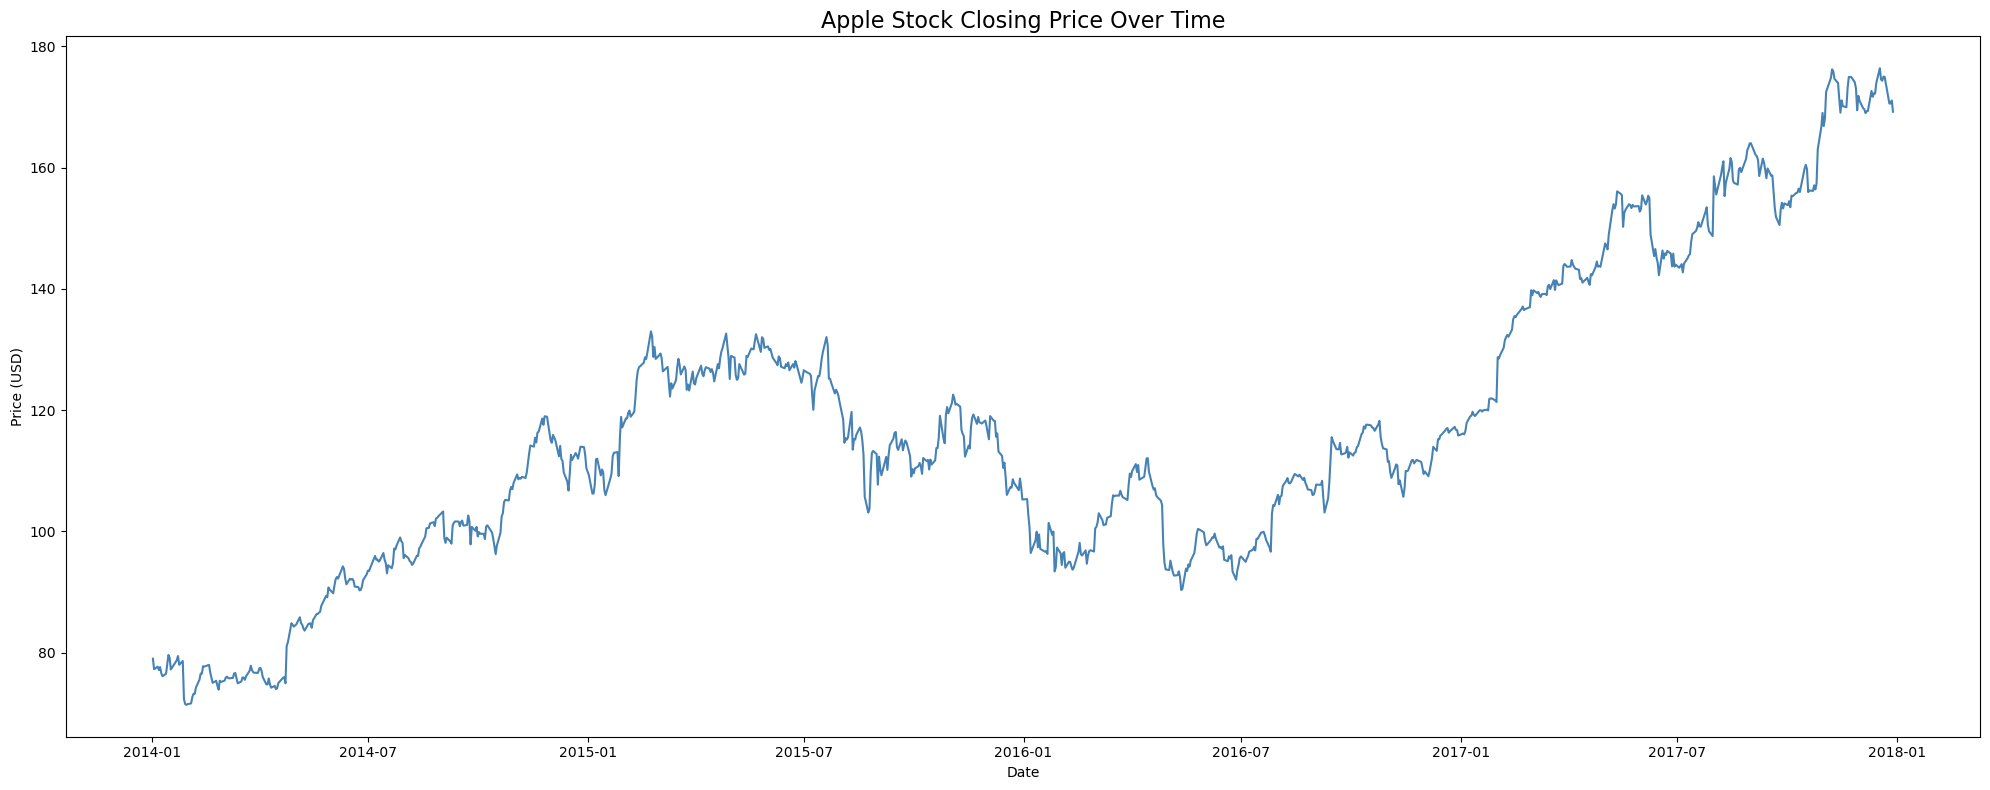

In [32]:
plt.figure(figsize=(20, 8))
plt.plot(apple['close'], color='steelblue')
plt.title('Apple Stock Closing Price Over Time', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()

In [33]:
from statsmodels.tsa.seasonal import seasonal_decompose

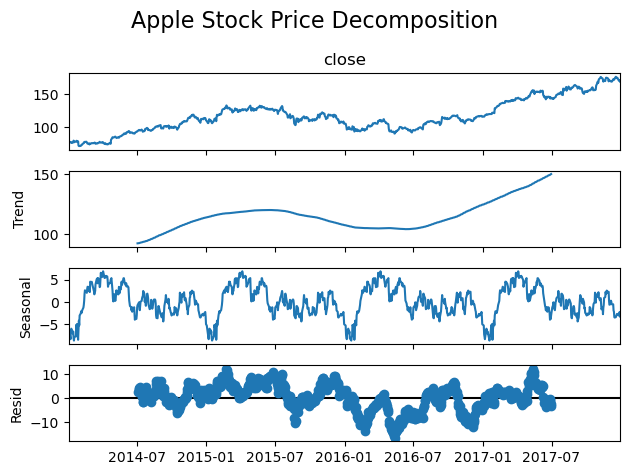

In [35]:
#Decomposition
#Period=252 (365 - 104(weekends) - 9 (holidays)
decomposition = seasonal_decompose(apple['close'], model='additive', period=252)
decomposition.plot()
plt.suptitle('Apple Stock Price Decomposition', fontsize=16)
plt.tight_layout()
plt.show()

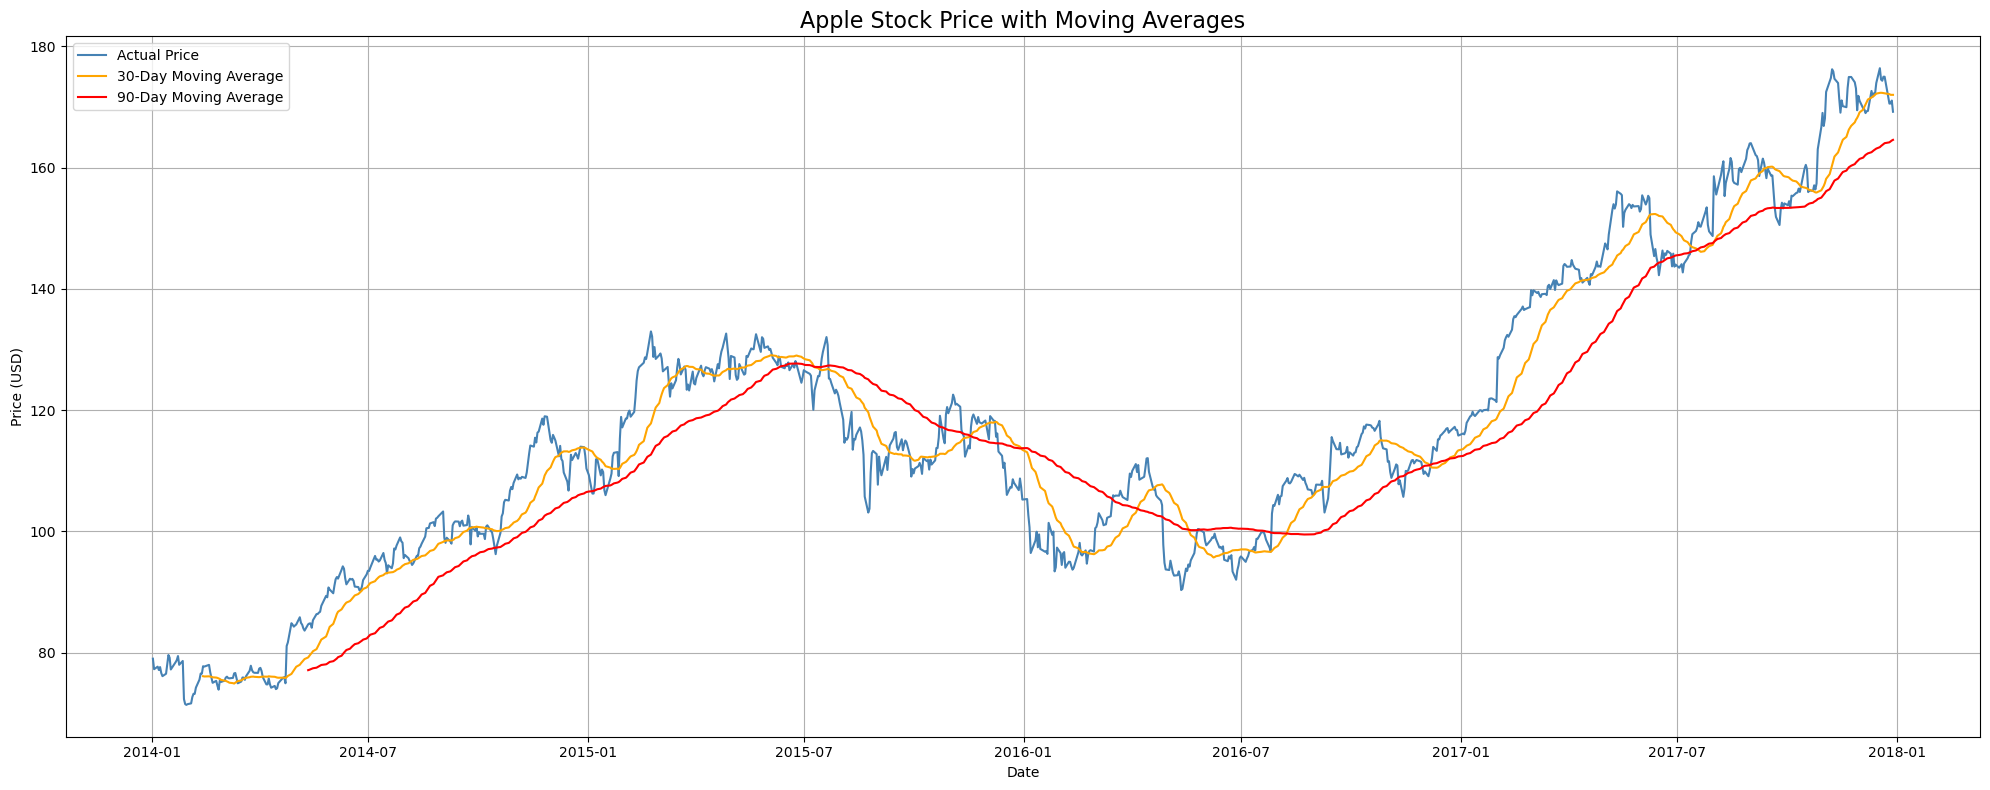

In [37]:
#Moving Average
apple['MA_30'] = apple['close'].rolling(window=30).mean()
apple['MA_90'] = apple['close'].rolling(window=90).mean()

plt.figure(figsize=(20, 8))
plt.plot(apple['close'], color='steelblue', label='Actual Price')
plt.plot(apple['MA_30'], color='orange', label='30-Day Moving Average')
plt.plot(apple['MA_90'], color='red', label='90-Day Moving Average')
plt.title('Apple Stock Price with Moving Averages', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()